# **Fake Product Review Identification**
### NLP Project

# **Importing Necessery Libraries**

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
import joblib
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# **Data Loading and Initial Exploration**

In [52]:
df = pd.read_csv("fake reviews dataset.csv", engine='python', on_bad_lines='skip')

In [53]:
if 'text_' in df.columns:
    df.rename(columns={'text_': 'text'}, inplace=True)

In [54]:
df.head()

,category,rating,label,text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  str    
 1   rating    40432 non-null  float64
 2   label     40432 non-null  str    
 3   text      40432 non-null  str    
dtypes: float64(1), str(3)
memory usage: 15.5 MB


# **Data Cleaning**

In [56]:
df.isnull().sum()

category    0
rating      0
label       0
text        0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(12)

In [58]:
df.drop_duplicates(inplace=True)

In [59]:
df.dropna(subset=['text', 'rating', 'label', 'category'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [60]:
df['label'] = df['label'].str.strip().map({'CG': 0, 'OR': 1})
df.dropna(subset=['label'], inplace=True)   
df['label'] = df['label'].astype(int)

print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
1    20215
0    20205
Name: count, dtype: int64


In [61]:
df['category'] = (
    df['category']
    .str.strip()
    .str.replace(r'_5$', '', regex=True)   
    .str.replace('_', ' ')                
    .str.strip()
    .str.title()                            
)

print("Categories found:", df['category'].unique())

Categories found: <ArrowStringArray>
[          'Home And Kitchen',        'Sports And Outdoors',
                'Electronics',              'Movies And Tv',
 'Tools And Home Improvement',               'Pet Supplies',
               'Kindle Store',                      'Books',
             'Toys And Games', 'Clothing Shoes And Jewelry']
Length: 10, dtype: str


In [62]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.dropna(subset=['rating'], inplace=True)
df['rating'] = df['rating'].astype(int)
df = df[df['rating'].between(1, 5)]  

print(f"Rating range: {df['rating'].min()} {df['rating'].max()}")
print(f"Shape: {df.shape}")

Rating range: 1 5
Shape: (40420, 4)


In [63]:
CONTRACTIONS = {
    "don't":"do not","won't":"will not","can't":"cannot","couldn't":"could not",
    "wouldn't":"would not","shouldn't":"shouldn't","isn't":"is not","aren't":"are not",
    "wasn't":"was not","weren't":"were not","hasn't":"has not","haven't":"have not",
    "hadn't":"had not","doesn't":"does not","didn't":"did not","it's":"it is",
    "i'm":"i am","i've":"i have","i'll":"i will","i'd":"i would",
    "you're":"you are","you've":"you have","you'll":"you will","you'd":"you would",
    "he's":"he is","she's":"she is","they're":"they are","they've":"they have",
    "they'll":"they will","we're":"we are","we've":"we have","we'll":"we will",
    "that's":"that is","there's":"there is","what's":"what is","who's":"who is",
    "let's":"let us","here's":"here is","how's":"how is","where's":"where is",
}

In [64]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    for contraction, expanded in CONTRACTIONS.items():
        text = text.replace(contraction, expanded)

    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [65]:
df['text'] = df['text'].apply(clean_text)

empty_before = len(df)
df = df[df['text'].str.len() > 0]
print(f"Removed {empty_before - len(df)} empty reviews after cleaning")
print(f"Shape: {df.shape}")

Removed 1 empty reviews after cleaning
Shape: (40419, 4)


In [66]:
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

df = df[df['word_count'] >= 3]
df.reset_index(drop=True, inplace=True)

print(f"Shape after filtering short reviews: {df.shape}")
print(f"Text length — mean: {df['text_length'].mean():.1f}, max: {df['text_length'].max()}")
print(f"Word count  — mean: {df['word_count'].mean():.1f}, max: {df['word_count'].max()}")

Shape after filtering short reviews: (40418, 6)
Text length — mean: 342.2, max: 2722
Word count  — mean: 69.3, max: 524


In [67]:
df = df[['category', 'rating', 'label', 'text', 'text_length', 'word_count']]
df.reset_index(drop=True, inplace=True)

In [68]:
df.shape

(40418, 6)

In [69]:
df.head()

,category,rating,label,text,text_length,word_count
0,Home And Kitchen,5,0,love this well made sturdy and very comfortabl...,69,13
1,Home And Kitchen,5,0,love it a great upgrade from the original i ha...,79,17
2,Home And Kitchen,5,0,this pillow saved my back i love the look and ...,65,14
3,Home And Kitchen,1,0,missing information on how to use it but it is...,78,17
4,Home And Kitchen,5,0,very nice set good quality we have had the set...,83,18


# Tokenization & Stopwords Analysis

In [70]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

True

In [71]:
stop_words = set(stopwords.words('english'))  

In [72]:
# Tokenization 
df['tokens']          = df['text'].apply(lambda t: t.split())
df['token_count']     = df['tokens'].apply(len)
df['stopword_tokens'] = df['tokens'].apply(lambda tks: [w for w in tks if w in stop_words])
df['content_tokens']  = df['tokens'].apply(lambda tks: [w for w in tks if w not in stop_words and len(w) > 2])
df['stopword_count']  = df['stopword_tokens'].apply(len)
df['content_count']   = df['content_tokens'].apply(len)
df['stopword_ratio']  = (df['stopword_count'] / df['token_count'].replace(0, 1)).round(4)


In [73]:
print("        Tokenization Summary")
print(f"  Avg Words per Review         : {df['token_count'].mean():.1f}")
print(f"  Avg Stop Words per Review    : {df['stopword_count'].mean():.1f}")
print(f"  Avg Content Words per Review : {df['content_count'].mean():.1f}")
print(f"  Avg Stop Words Ratio         : {df['stopword_ratio'].mean() * 100:.1f}%")

        Tokenization Summary
  Avg Words per Review         : 69.3
  Avg Stop Words per Review    : 37.4
  Avg Content Words per Review : 31.1
  Avg Stop Words Ratio         : 53.0%


C:\Users\elmnshawy\AppData\Local\Temp\ipykernel_7160\2323254807.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(groups, patch_artist=True, labels=['Fake (CG)', 'Real (OR)'],


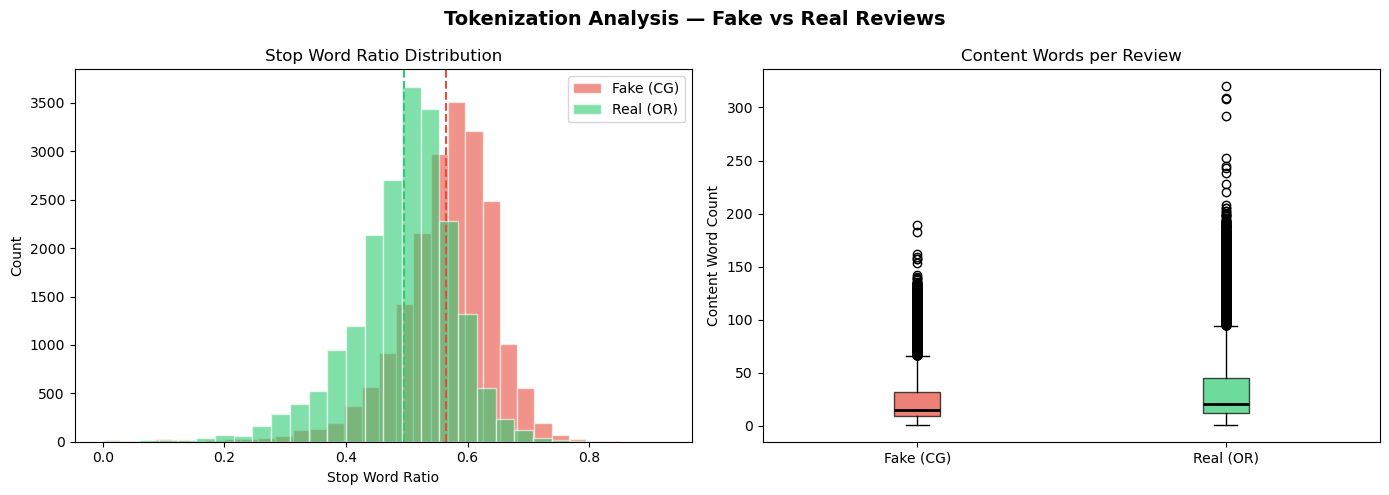

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tokenization Analysis — Fake vs Real Reviews', fontsize=14, fontweight='bold')

for lbl, color, name in [(0,'#e74c3c','Fake (CG)'), (1,'#2ecc71','Real (OR)')]:
    axes[0].hist(df[df['label']==lbl]['stopword_ratio'],
                 bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Stop Word Ratio Distribution')
axes[0].set_xlabel('Stop Word Ratio')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(df[df['label']==0]['stopword_ratio'].mean(), color='#e74c3c', linestyle='--', lw=1.5)
axes[0].axvline(df[df['label']==1]['stopword_ratio'].mean(), color='#2ecc71', linestyle='--', lw=1.5)


groups = [df[df['label']==0]['content_count'].values,
          df[df['label']==1]['content_count'].values]
bp = axes[1].boxplot(groups, patch_artist=True, labels=['Fake (CG)', 'Real (OR)'],
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Content Words per Review')
axes[1].set_ylabel('Content Word Count')

plt.tight_layout()
plt.show()

In [75]:
print("Stop Word Ratio — Group Comparison:")
print(df.groupby('label')[['stopword_ratio','content_count','token_count']]
        .mean().rename(index={0:'Fake (CG)', 1:'Real (OR)'}).round(3).to_string())


Stop Word Ratio — Group Comparison:
           stopword_ratio  content_count  token_count
label                                                
Fake (CG)           0.565         25.940       63.138
Real (OR)           0.495         36.195       75.476


In [76]:
def top_words(label_val, n=20):
    all_tokens = []
    for tks in df[df['label'] == label_val]['content_tokens']:
        all_tokens.extend(tks)
    return Counter(all_tokens).most_common(n)

In [77]:
fake_top = top_words(0)
real_top = top_words(1)


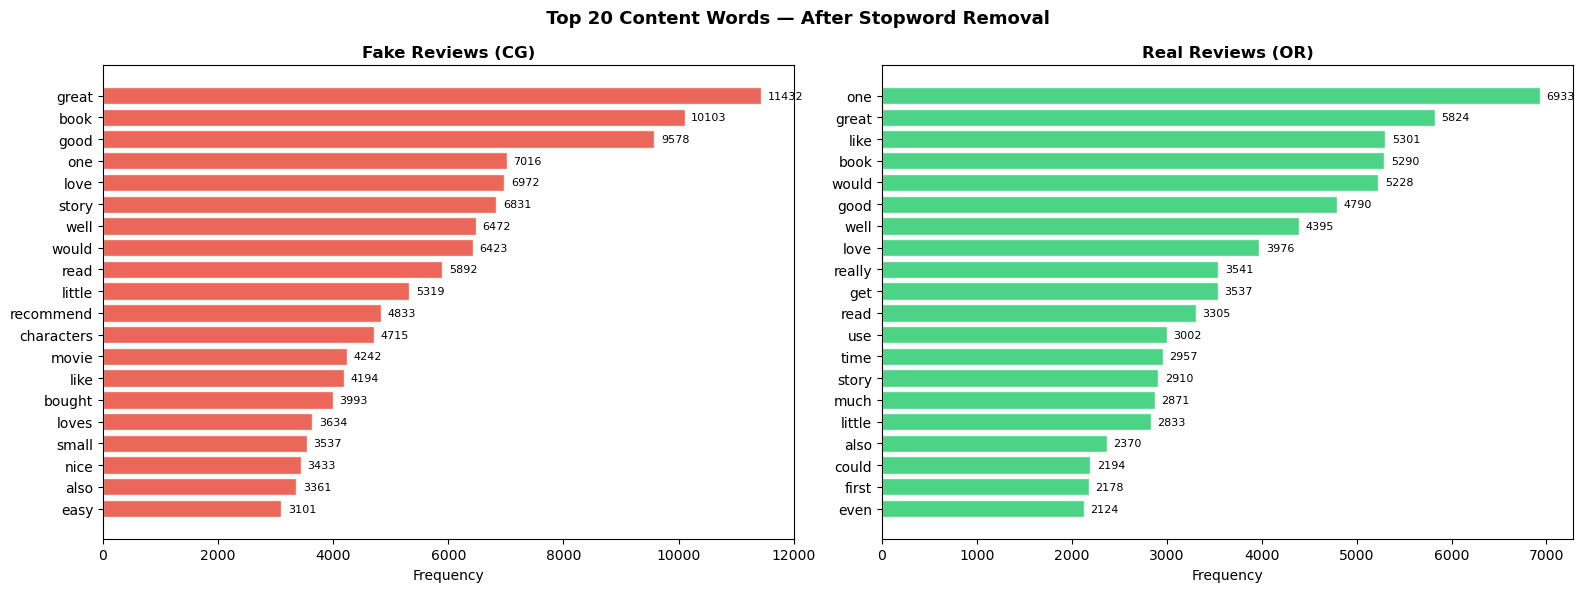

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Top 20 Content Words — After Stopword Removal', fontsize=13, fontweight='bold')

for ax, top, color, title in [
    (axes[0], fake_top, '#e74c3c', 'Fake Reviews (CG)'),
    (axes[1], real_top, '#2ecc71', 'Real Reviews (OR)')
]:
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    for i, (w, c) in enumerate(zip(list(words)[::-1], list(counts)[::-1])):
        ax.text(c + max(counts)*0.01, i, str(c), va='center', fontsize=8)

plt.tight_layout()
plt.show()


---
# Normalization & Stemming

Objective: Compare three word normalization techniques:

Porter Stemmer — Fast but may produce truncated roots (e.g., running → run)
Snowball Stemmer — More advanced and accurate than Porter
WordNet Lemmatizer  — Produces linguistically correct base forms (e.g., better → good)

In [79]:
porter     = PorterStemmer()
snowball   = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer() 

In [80]:
def normalize_base(text):
    """Lowercase + إزالة الأرقام والرموز"""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [81]:
sample_texts = df['text'].sample(5, random_state=42).tolist()
print("   Normalization & Stemming — Comparison on Real Samples")

   Normalization & Stemming — Comparison on Real Samples


In [82]:
for i, raw in enumerate(sample_texts, 1):
    base   = normalize_base(raw)
    tokens = [w for w in base.split() if w not in stop_words and len(w) > 2]

    porter_r   = [porter.stem(w)      for w in tokens]
    snowball_r = [snowball.stem(w)     for w in tokens]
    lemma_r    = [lemmatizer.lemmatize(w) for w in tokens]

    print(f"\n[Sample {i}]")
    print(f"  Original   : {' '.join(tokens[:8])} ...")
    print(f"  Porter     : {' '.join(porter_r[:8])} ...")
    print(f"  Snowball   : {' '.join(snowball_r[:8])} ...")
    print(f"  Lemmatizer : {' '.join(lemma_r[:8])} ...")



[Sample 1]
  Original   : well made hat soft comfortable great quality also ...
  Porter     : well made hat soft comfort great qualiti also ...
  Snowball   : well made hat soft comfort great qualiti also ...
  Lemmatizer : well made hat soft comfortable great quality also ...

[Sample 2]
  Original   : love shear bought clean face maltese shitzu puppy ...
  Porter     : love shear bought clean face maltes shitzu puppi ...
  Snowball   : love shear bought clean face maltes shitzu puppi ...
  Lemmatizer : love shear bought clean face maltese shitzu puppy ...

[Sample 3]
  Original   : still buy balls disappointed perfect size ...
  Porter     : still buy ball disappoint perfect size ...
  Snowball   : still buy ball disappoint perfect size ...
  Lemmatizer : still buy ball disappointed perfect size ...

[Sample 4]
  Original   : nothing still combing huge hay problem kind hard ...
  Porter     : noth still comb huge hay problem kind hard ...
  Snowball   : noth still comb huge hay pro

In [83]:
def build_vocab(series):
    all_words = []
    for text in series:
        all_words.extend(str(text).split())
    return set(all_words)

In [84]:
def apply_strategy(texts, stem_fn):
    results = []
    for text in texts:
        base   = normalize_base(text)
        tokens = [w for w in base.split() if w not in stop_words and len(w) > 2]
        results.append(' '.join([stem_fn(w) for w in tokens]))
    return results

In [85]:
sample_texts_series = df['text'].head(5000)

raw_vocab      = build_vocab(sample_texts_series)
porter_vocab   = build_vocab(apply_strategy(sample_texts_series, porter.stem))
snowball_vocab = build_vocab(apply_strategy(sample_texts_series, snowball.stem))
lemma_vocab    = build_vocab(apply_strategy(sample_texts_series, lemmatizer.lemmatize))


In [86]:
vocab_data = {
    'Strategy'   : ['Raw Text', 'Porter Stemmer', 'Snowball Stemmer', 'Lemmatizer '],
    'Vocab Size' : [len(raw_vocab), len(porter_vocab), len(snowball_vocab), len(lemma_vocab)],
    'Reduction %': [
        0,
        round((1 - len(porter_vocab)   / len(raw_vocab)) * 100, 1),
        round((1 - len(snowball_vocab) / len(raw_vocab)) * 100, 1),
        round((1 - len(lemma_vocab)    / len(raw_vocab)) * 100, 1),
    ]
}

vocab_df = pd.DataFrame(vocab_data)
print(vocab_df.to_string(index=False))

        Strategy  Vocab Size  Reduction %
        Raw Text        9190          0.0
  Porter Stemmer        5909         35.7
Snowball Stemmer        5835         36.5
     Lemmatizer         7591         17.4


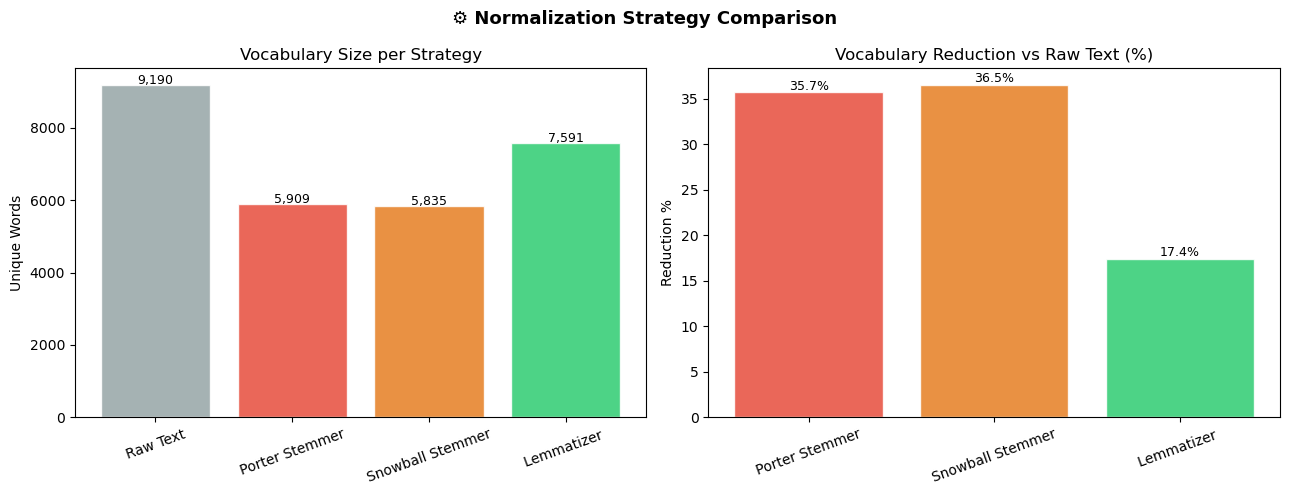

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('⚙️ Normalization Strategy Comparison', fontsize=13, fontweight='bold')

colors = ['#95a5a6', '#e74c3c', '#e67e22', '#2ecc71']
axes[0].bar(vocab_df['Strategy'], vocab_df['Vocab Size'], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Vocabulary Size per Strategy')
axes[0].set_ylabel('Unique Words')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(vocab_df['Vocab Size']):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(vocab_df['Strategy'][1:], vocab_df['Reduction %'][1:],
            color=colors[1:], alpha=0.85, edgecolor='white')
axes[1].set_title('Vocabulary Reduction vs Raw Text (%)')
axes[1].set_ylabel('Reduction %')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(vocab_df['Reduction %'][1:]):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [88]:
test_words = ['running','studies','better','wolves','happily',
              'flies','went','caring','cities','busiest']

In [89]:
print(f"{'Word':<12} {'Porter':<15} {'Snowball':<15} {'Lemmatizer '}")
print("-" * 58)

for w in test_words:
    p = porter.stem(w)
    s = snowball.stem(w)
    l = lemmatizer.lemmatize(w)
    print(f"  {w:<10} {p:<15} {s:<15} {l}")

Word         Porter          Snowball        Lemmatizer 
----------------------------------------------------------
  running    run             run             running
  studies    studi           studi           study
  better     better          better          better
  wolves     wolv            wolv            wolf
  happily    happili         happili         happily
  flies      fli             fli             fly
  went       went            went            went
  caring     care            care            caring
  cities     citi            citi            city
  busiest    busiest         busiest         busiest


# **Exploratory Data Analysis (EDA)**

label
1    20215
0    20203
Name: count, dtype: int64


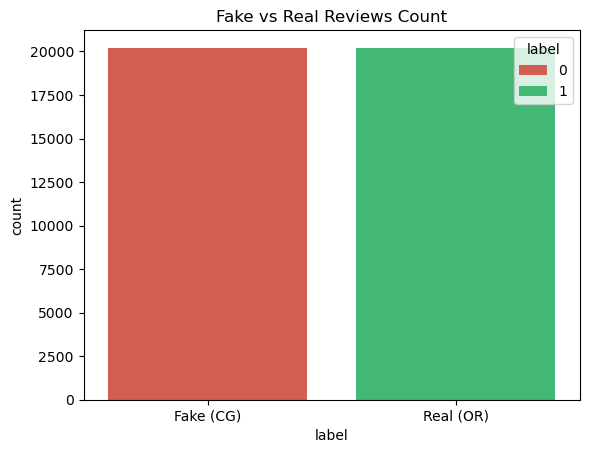

In [90]:
print(df['label'].value_counts())
sns.countplot(data=df, x='label', hue='label', palette=['#e74c3c', '#2ecc71'], legend=True)
plt.title('Fake vs Real Reviews Count')
plt.xticks([0, 1], ['Fake (CG)', 'Real (OR)'])
plt.show()

         Fake   Real  Total  Fake Rate %
rating                                  
1        1063   1092   2155         49.3
2         962   1005   1967         48.9
3        1952   1834   3786         51.6
4        3919   4045   7964         49.2
5       12307  12239  24546         50.1


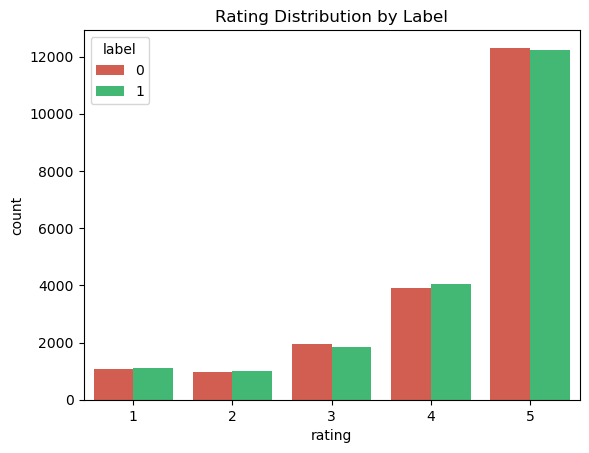

In [91]:
counts = df.groupby(['rating', 'label']).size().unstack()
counts.columns = ['Fake', 'Real']
counts['Total'] = counts.sum(axis=1)
counts['Fake Rate %'] = (counts['Fake'] / counts['Total'] * 100).round(1)
print(counts)

sns.countplot(data=df, x='rating', hue='label', palette=['#e74c3c', '#2ecc71'], legend=True)
plt.title('Rating Distribution by Label')
plt.show()

                            Fake  Real  Total  Fake Rate %
category                                                  
Books                       2184  2185   4369         50.0
Clothing Shoes And Jewelry  1922  1924   3846         50.0
Electronics                 1994  1994   3988         50.0
Home And Kitchen            2028  2028   4056         50.0
Kindle Store                2363  2365   4728         50.0
Movies And Tv               1793  1794   3587         50.0
Pet Supplies                2124  2126   4250         50.0
Sports And Outdoors         1971  1973   3944         50.0
Tools And Home Improvement  1929  1929   3858         50.0
Toys And Games              1895  1897   3792         50.0


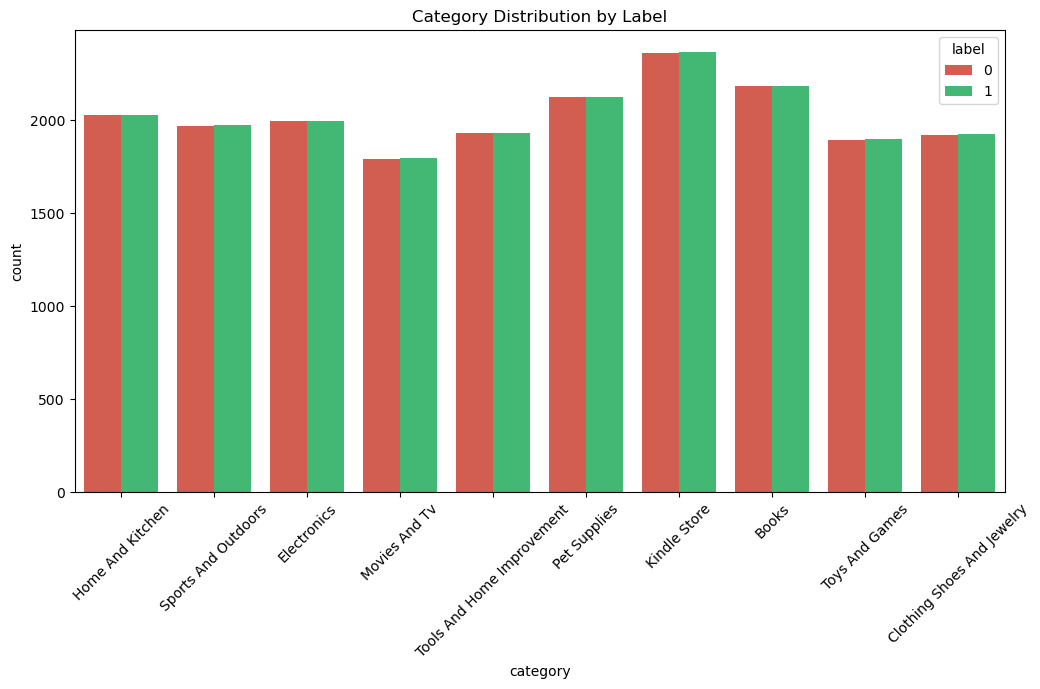

In [92]:
counts = df.groupby(['category', 'label']).size().unstack()
counts.columns = ['Fake', 'Real']
counts['Total'] = counts.sum(axis=1)
counts['Fake Rate %'] = (counts['Fake'] / counts['Total'] * 100).round(1)
print(counts)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', hue='label', palette=['#e74c3c', '#2ecc71'], legend=True)
plt.title('Category Distribution by Label')
plt.xticks(rotation=45)
plt.show()

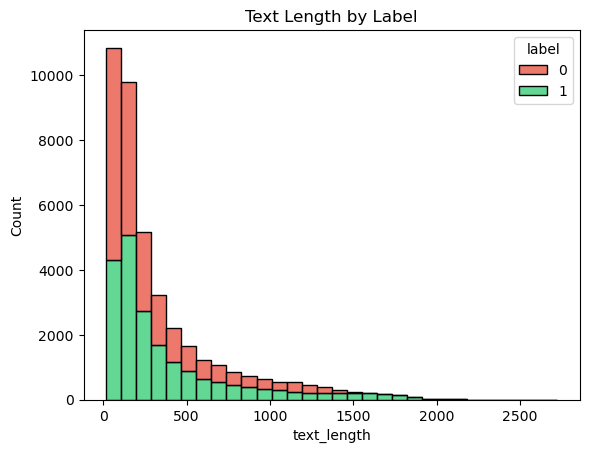

In [93]:
sns.histplot(data=df, x='text_length', hue='label',
             palette=['#e74c3c', '#2ecc71'], bins=30, multiple='stack')
plt.title('Text Length by Label')
plt.show()

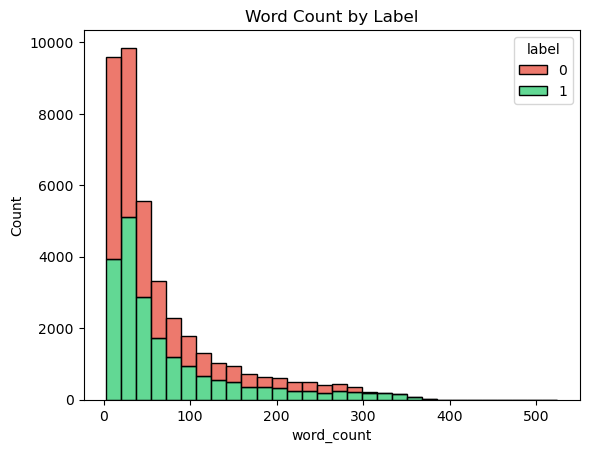

In [94]:
sns.histplot(data=df, x='word_count', hue='label',
             palette=['#e74c3c', '#2ecc71'], bins=30, multiple='stack')
plt.title('Word Count by Label')
plt.show()

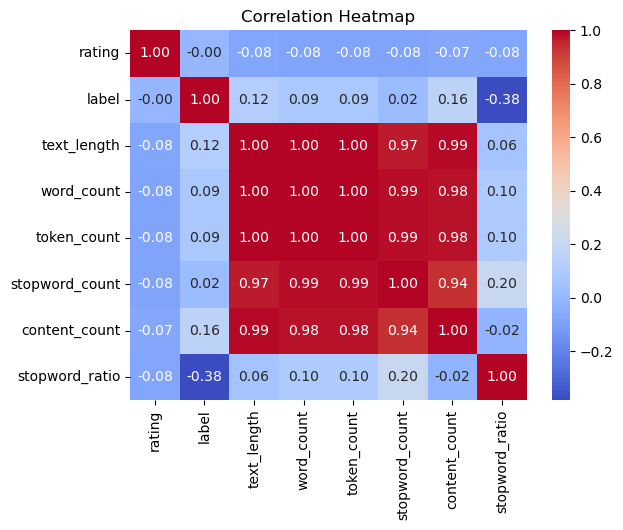

In [95]:
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

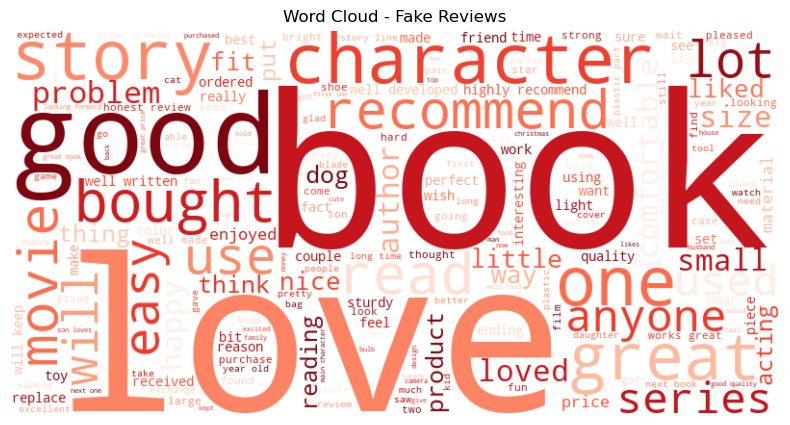

In [96]:
fake_text = ' '.join(df[df['label'] == 0]['text'])
wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds').generate(fake_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Fake Reviews')
plt.show()

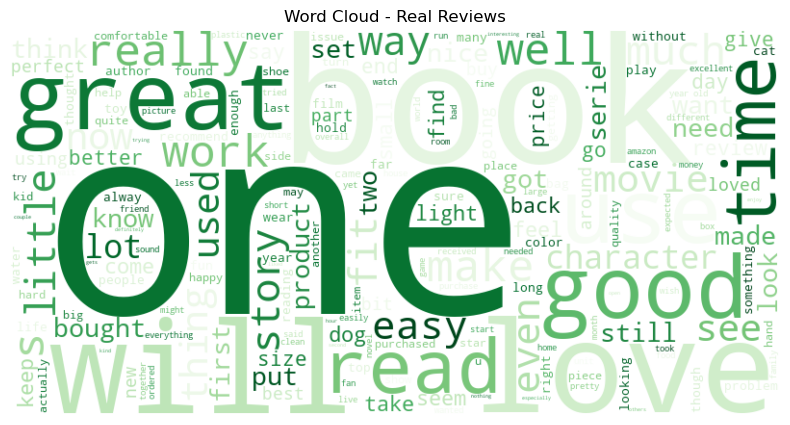

In [97]:
real_text = ' '.join(df[df['label'] == 1]['text'])
wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens').generate(real_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Real Reviews')
plt.show()

# ***Data Preprocessing***

In [98]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elmnshawy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\elmnshawy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\elmnshawy\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [99]:
def preprocess_text(text):

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()

    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

In [100]:
le = LabelEncoder()

df['category_encoded'] = le.fit_transform(df['category'])

In [101]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_text = tfidf.fit_transform(df['processed_text'])


X_extra = df[['rating', 'category_encoded']].values

X_final = hstack([X_text, csr_matrix(X_extra)])

y = df['label']

# ***Data Modeling***


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2,random_state=42,stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (32334, 10002), Test: (8084, 10002)


# ***LogisticRegression***

In [103]:
lr_model = LogisticRegression(max_iter=1000, random_state=42 )
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [104]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")

Accuracy: 89.14 %


# Evaluation

In [105]:
print(classification_report(y_test, y_pred_lr,target_names=['Fake (CG)', 'Real (OR)']))

              precision    recall  f1-score   support

   Fake (CG)       0.89      0.89      0.89      4041
   Real (OR)       0.89      0.89      0.89      4043

    accuracy                           0.89      8084
   macro avg       0.89      0.89      0.89      8084
weighted avg       0.89      0.89      0.89      8084



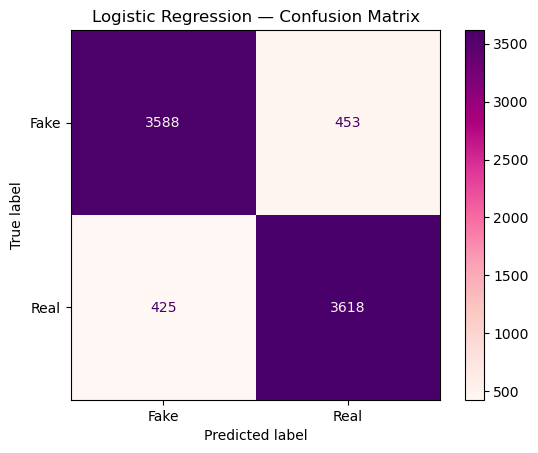

In [106]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='RdPu')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

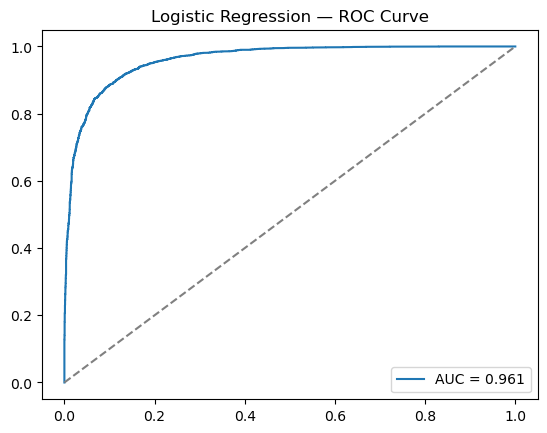

In [107]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('Logistic Regression — ROC Curve')
plt.legend()
plt.show()

# ***Naive Bayes***

In [108]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

In [109]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')

Accuracy: 0.8747


# Evaluation

In [110]:
print(classification_report(y_test, y_pred_nb, target_names=['Fake (CG)', 'Real (OR)']))

              precision    recall  f1-score   support

   Fake (CG)       0.88      0.87      0.87      4041
   Real (OR)       0.87      0.88      0.88      4043

    accuracy                           0.87      8084
   macro avg       0.87      0.87      0.87      8084
weighted avg       0.87      0.87      0.87      8084



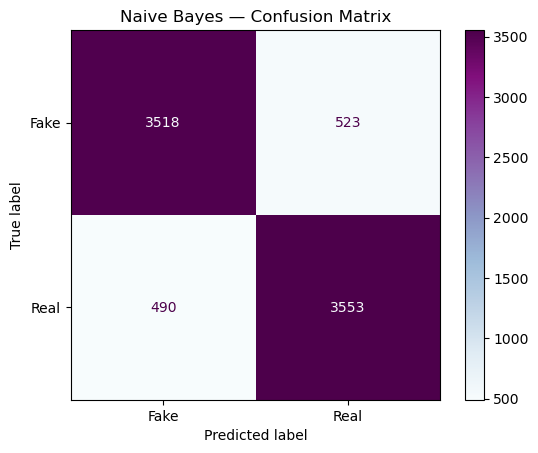

In [111]:
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='BuPu')
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

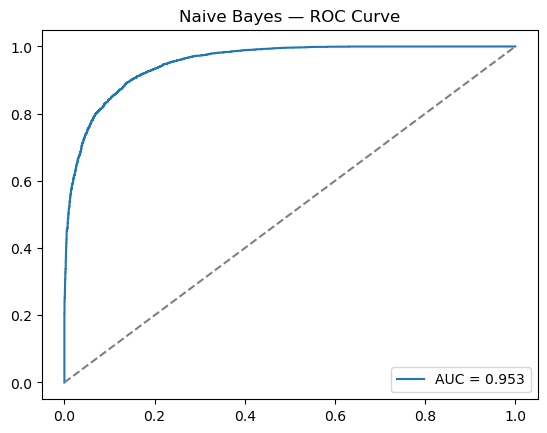

In [112]:
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
auc = roc_auc_score(y_test, y_prob_nb)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('Naive Bayes — ROC Curve')
plt.legend()
plt.show()

# **Support Vector Machine(SVM)**

In [113]:
svm_base  = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=5)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]


In [114]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')

Accuracy: 0.9030


# Evaluation

In [115]:
print(classification_report(y_test, y_pred_svm, target_names=['Fake (CG)', 'Real (OR)']))

              precision    recall  f1-score   support

   Fake (CG)       0.90      0.91      0.90      4041
   Real (OR)       0.91      0.90      0.90      4043

    accuracy                           0.90      8084
   macro avg       0.90      0.90      0.90      8084
weighted avg       0.90      0.90      0.90      8084



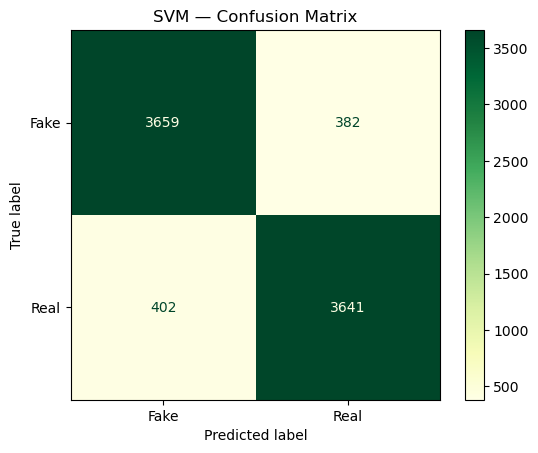

In [116]:
cm   = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='YlGn')
plt.title('SVM — Confusion Matrix')
plt.show()

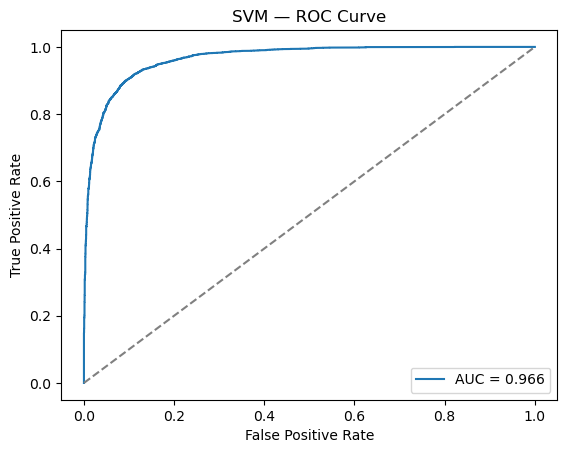

In [117]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc          = roc_auc_score(y_test, y_prob_svm)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('SVM — ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


# ***Random Forest***

In [118]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [119]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

Accuracy: 0.8627


# Evaluation

In [120]:
print(classification_report(y_test, y_pred_rf, target_names=['Fake (CG)', 'Real (OR)']))

              precision    recall  f1-score   support

   Fake (CG)       0.87      0.85      0.86      4041
   Real (OR)       0.86      0.87      0.86      4043

    accuracy                           0.86      8084
   macro avg       0.86      0.86      0.86      8084
weighted avg       0.86      0.86      0.86      8084



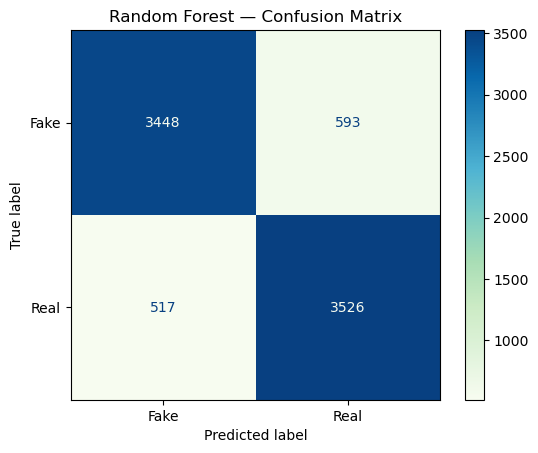

In [121]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='GnBu')
plt.title('Random Forest — Confusion Matrix')
plt.show()

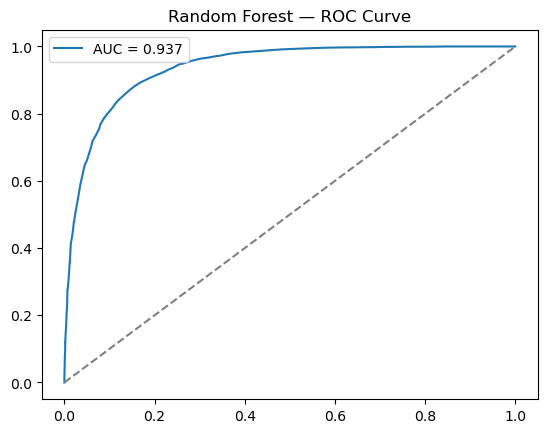

In [122]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('Random Forest — ROC Curve')
plt.legend()
plt.show()

# ***XGBoost***

In [123]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [124]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')

Accuracy: 0.8428


# Evaluation

In [125]:
print(classification_report(y_test, y_pred_xgb, target_names=['Fake (CG)', 'Real (OR)']))

              precision    recall  f1-score   support

   Fake (CG)       0.87      0.81      0.84      4041
   Real (OR)       0.82      0.88      0.85      4043

    accuracy                           0.84      8084
   macro avg       0.84      0.84      0.84      8084
weighted avg       0.84      0.84      0.84      8084



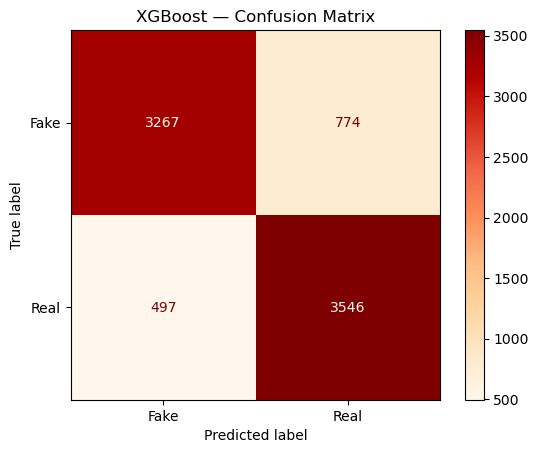

In [126]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='OrRd')
plt.title('XGBoost — Confusion Matrix')
plt.show()

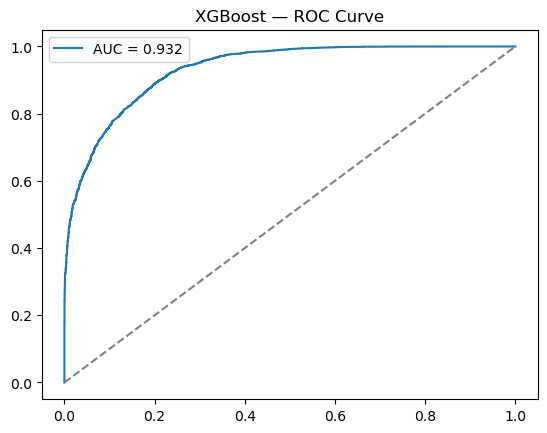

In [127]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc = roc_auc_score(y_test, y_prob_xgb)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('XGBoost — ROC Curve')
plt.legend()
plt.show()

# **Model Comparison Summary**

In [128]:
results = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr) * 100, 2),
        round(accuracy_score(y_test, y_pred_nb) * 100, 2),
        round(accuracy_score(y_test, y_pred_svm) * 100, 2),
        round(accuracy_score(y_test, y_pred_rf) * 100, 2),
        round(accuracy_score(y_test, y_pred_xgb) * 100, 2),
    ]
}

              Model  Accuracy
                SVM     90.30
Logistic Regression     89.14
        Naive Bayes     87.47
      Random Forest     86.27
            XGBoost     84.28


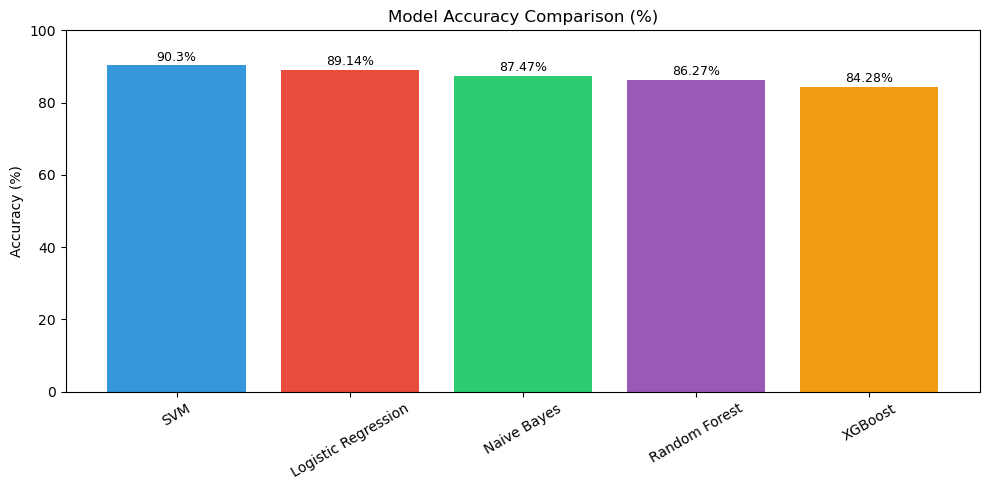

In [129]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors)
plt.title('Model Accuracy Comparison (%)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=30)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# **Save Models**

In [130]:
joblib.dump(lr_model, 'model_logistic_regression.pkl')
joblib.dump(nb_model, 'model_naive_bayes.pkl')
joblib.dump(svm_model, 'model_svm.pkl')
joblib.dump(rf_model, 'model_random_forest.pkl')
joblib.dump(xgb_model, 'model_xgboost.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']